# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

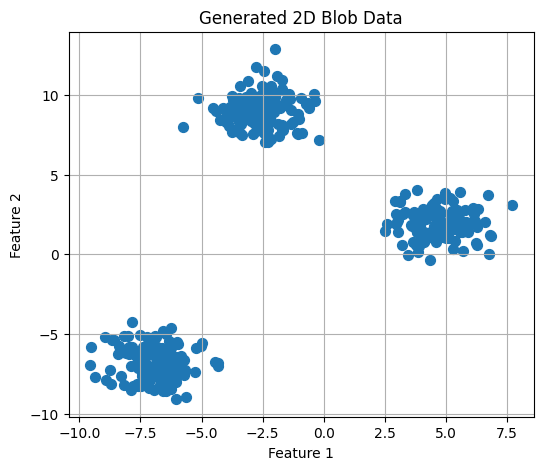

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


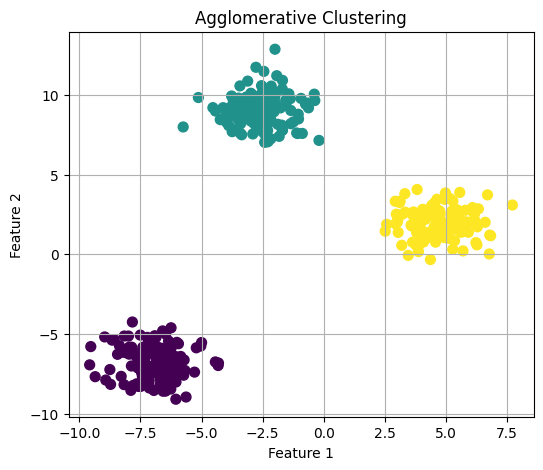

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

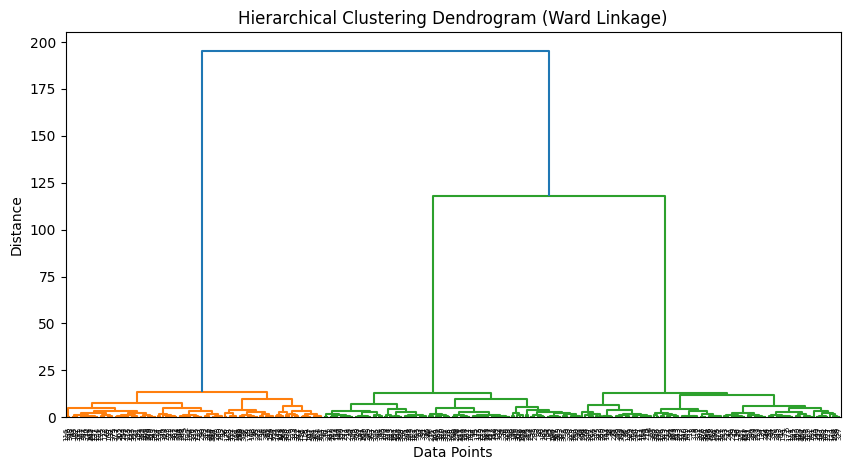

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
import numpy as A
import matplotlib.pyplot as plt

# 1) Load the dataset from CSV into a DataFrame
df = pd.read_csv("CC GENERAL.csv")


In [ ]:
# Show basic shape + first rows
print("Shape (rows, cols):", df.shape)


Shape (rows, cols): (8950, 18)


In [88]:
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Credit Card Customer Dataset Description

This dataset contains information about credit card customers.
Each row represents one customer, and the columns describe their
credit usage behavior, purchasing patterns, and repayment activity.

---

## Feature Description

### Categorical Feature
- **CUST_ID** → Unique customer identifier (high cardinality).

---

### Numerical Features (Continuous)

- **BALANCE** → Current balance amount on the credit card.
- **BALANCE_FREQUENCY** → Frequency of balance updates (ratio between 0 and 1).
- **PURCHASES** → Total purchase amount.
- **ONEOFF_PURCHASES** → Amount spent on one-time purchases.
- **INSTALLMENTS_PURCHASES** → Amount spent on installment purchases.
- **CASH_ADVANCE** → Total cash advance amount.
- **PURCHASES_FREQUENCY** → Frequency of purchases (ratio between 0 and 1).
- **ONEOFF_PURCHASES_FREQUENCY** → Frequency of one-time purchases (ratio between 0 and 1).
- **PURCHASES_INSTALLMENTS_FREQUENCY** → Frequency of installment purchases (ratio between 0 and 1).
- **CASH_ADVANCE_FREQUENCY** → Frequency of cash advances (ratio between 0 and 1).
- **CREDIT_LIMIT** → Credit card limit.
- **PAYMENTS** → Total payments made.
- **MINIMUM_PAYMENTS** → Minimum payments made.
- **PRC_FULL_PAYMENT** → Percentage of full payments made (ratio between 0 and 1).

---

### Numerical Features (Discrete)

- **CASH_ADVANCE_TRX** → Number of cash advance transactions.
- **PURCHASES_TRX** → Number of purchase transactions.
- **TENURE** → Number of months the customer has been active.

In [89]:
# 2) Column names + dtypes
print("Columns:")
print(df.columns.tolist())

print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))

Columns:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Dtypes:


,dtype
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [90]:
#select the numeric columns of the data set
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [91]:
#Print (min, max, mean, std, skewness)
numeric_summary = numeric_df.agg(['min', 'max', 'mean', 'std', 'skew']).T
numeric_summary
#skewness scale: =0 for normal distribution, x>(+,-)1 highly skewed 
#positive skewness at x>+1, long right tail 


,min,max,mean,std,skew
BALANCE,0.000000,19043.13856,1564.474828,2081.531879,2.393386
BALANCE_FREQUENCY,0.000000,1.00000,0.877271,0.236904,-2.023266
PURCHASES,0.000000,49039.57000,1003.204834,2136.634782,8.144269
ONEOFF_PURCHASES,0.000000,40761.25000,592.437371,1659.887917,10.045083
INSTALLMENTS_PURCHASES,0.000000,22500.00000,411.067645,904.338115,7.299120
CASH_ADVANCE,0.000000,47137.21176,978.871112,2097.163877,5.166609
PURCHASES_FREQUENCY,0.000000,1.00000,0.490351,0.401371,0.060164
ONEOFF_PURCHASES_FREQUENCY,0.000000,1.00000,0.202458,0.298336,1.535613
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000,1.00000,0.364437,0.397448,0.509201
CASH_ADVANCE_FREQUENCY,0.000000,1.50000,0.135144,0.200121,1.828686


In [92]:
categorical_df = df.select_dtypes(include=["object"])
categorical_df.columns

Index(['CUST_ID'], dtype='object')

In [93]:
for col in categorical_df.columns:
    print(f"\n===== {col} =====")
    print(df[col])


===== CUST_ID =====
0       C10001
1       C10002
2       C10003
3       C10004
4       C10005
         ...  
8945    C19186
8946    C19187
8947    C19188
8948    C19189
8949    C19190
Name: CUST_ID, Length: 8950, dtype: object


In [94]:
df.isnull().sum()



CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

,missing_count,missing_pct
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


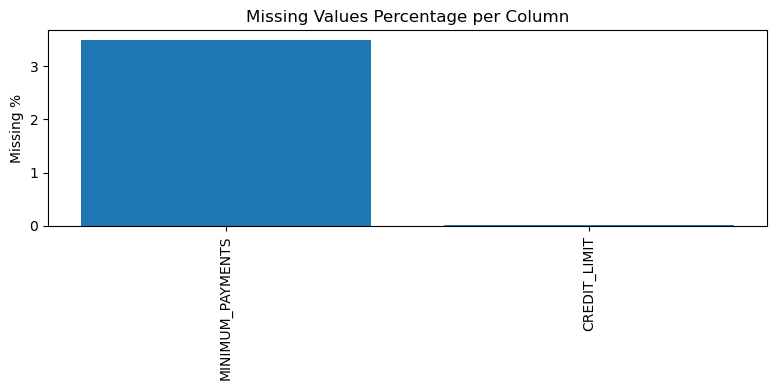

In [95]:
# Missing values count + percentage
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

# Show only columns with missing
missing_table = missing_table[missing_table["missing_count"] > 0]
display(missing_table)

# Plot missing % (if any)
if len(missing_table) > 0:
    plt.figure(figsize=(8,4))
    plt.bar(missing_table.index, missing_table["missing_pct"])
    plt.xticks(rotation=90)
    plt.ylabel("Missing %")
    plt.title("Missing Values Percentage per Column")
    plt.tight_layout()
    plt.show()

since the data missing is less than 5% it is safe to either impute with median or drop missing
I will:
-drop the one customer with the missing credit limit
-impute the minimum payments with median

In [96]:
#investigating correlations
corr_matrix = numeric_df.corr()
corr_matrix


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303985,0.453238,0.140107,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119788,0.103464,0.003030,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295038,0.243537,-0.030327,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060755,0.085551,0.030073,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132616,0.183192,0.098838,-0.249773,-0.133372


In [97]:
#check for high correlated columns for |corr|>0.7
import numpy as np

threshold = 0.7
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):   # avoid duplicates and self-correlation
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 round(corr_value, 3))
            )

high_corr_pairs

[('ONEOFF_PURCHASES', 'PURCHASES', 0.917),
 ('PURCHASES_INSTALLMENTS_FREQUENCY', 'PURCHASES_FREQUENCY', 0.863),
 ('CASH_ADVANCE_TRX', 'CASH_ADVANCE_FREQUENCY', 0.8)]

In [98]:
#detect outliers:
numeric_df = df.select_dtypes(include=["int64", "float64"])

outlier_counts = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = numeric_df[(numeric_df[col] < lower_bound) | 
                          (numeric_df[col] > upper_bound)]
    
    outlier_counts[col] = len(outliers)

outlier_counts

{'BALANCE': 695,
 'BALANCE_FREQUENCY': 1493,
 'PURCHASES': 808,
 'ONEOFF_PURCHASES': 1013,
 'INSTALLMENTS_PURCHASES': 867,
 'CASH_ADVANCE': 1030,
 'PURCHASES_FREQUENCY': 0,
 'ONEOFF_PURCHASES_FREQUENCY': 782,
 'PURCHASES_INSTALLMENTS_FREQUENCY': 0,
 'CASH_ADVANCE_FREQUENCY': 525,
 'CASH_ADVANCE_TRX': 804,
 'PURCHASES_TRX': 766,
 'CREDIT_LIMIT': 248,
 'PAYMENTS': 808,
 'MINIMUM_PAYMENTS': 841,
 'PRC_FULL_PAYMENT': 1474,
 'TENURE': 1366}

In [99]:
#outliers percentages
outlier_percentage = {
    col: (count / len(df)) * 100
    for col, count in outlier_counts.items()
}

outlier_percentage

{'BALANCE': 7.76536312849162,
 'BALANCE_FREQUENCY': 16.68156424581006,
 'PURCHASES': 9.027932960893855,
 'ONEOFF_PURCHASES': 11.318435754189943,
 'INSTALLMENTS_PURCHASES': 9.687150837988828,
 'CASH_ADVANCE': 11.508379888268157,
 'PURCHASES_FREQUENCY': 0.0,
 'ONEOFF_PURCHASES_FREQUENCY': 8.737430167597765,
 'PURCHASES_INSTALLMENTS_FREQUENCY': 0.0,
 'CASH_ADVANCE_FREQUENCY': 5.865921787709497,
 'CASH_ADVANCE_TRX': 8.983240223463687,
 'PURCHASES_TRX': 8.558659217877095,
 'CREDIT_LIMIT': 2.7709497206703912,
 'PAYMENTS': 9.027932960893855,
 'MINIMUM_PAYMENTS': 9.396648044692737,
 'PRC_FULL_PAYMENT': 16.46927374301676,
 'TENURE': 15.262569832402233}

high percentage of outliers require scaling

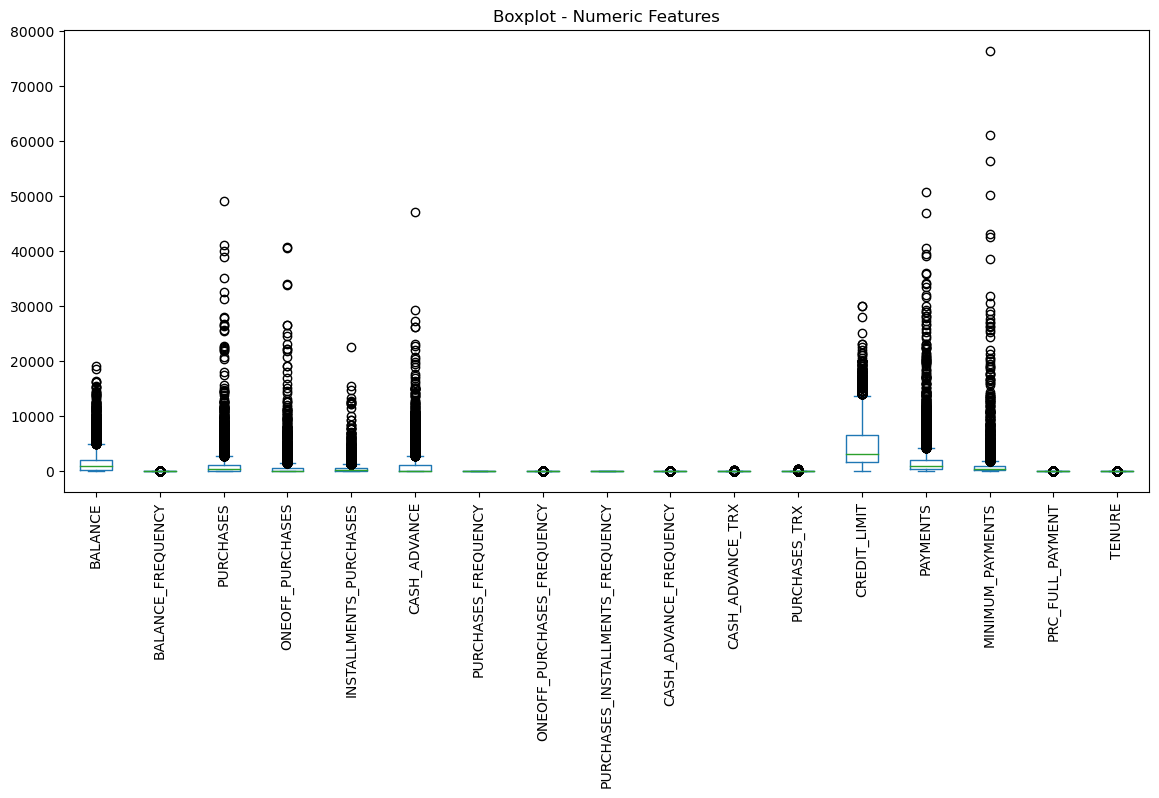

In [100]:
#boxplot for outliers
import matplotlib.pyplot as plt

numeric_df.plot(kind="box", figsize=(14,6), rot=90)
plt.title("Boxplot - Numeric Features")
plt.show()

## **2. Data Preparation**

In [101]:
# Drop rows where CREDIT_LIMIT is missing
df = df.dropna(subset=["CREDIT_LIMIT"])

print("Shape after dropping missing CREDIT_LIMIT:", df.shape)

Shape after dropping missing CREDIT_LIMIT: (8949, 18)


In [102]:
# Compute median before imputation (for reporting)
median_min_payment = df["MINIMUM_PAYMENTS"].median()
print("Median MINIMUM_PAYMENTS:", median_min_payment)

# Fill missing values with median
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(median_min_payment)

Median MINIMUM_PAYMENTS: 312.4522915


In [103]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

since high correlation between the next pairs: 
Keep PURCHASES, remove ONEOFF_PURCHASES

Keep PURCHASES_FREQUENCY, remove PURCHASES_INSTALLMENTS_FREQUENCY

Keep CASH_ADVANCE_FREQUENCY, remove CASH_ADVANCE_TRX

In [104]:
df = df.drop(columns=[
    "ONEOFF_PURCHASES",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_TRX"
])


In [105]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

CUST_ID completely should be removed before clustering since CUST_ID is:

A unique identifier

High cardinality (8950 unique values)

Has no behavioral meaning

Artificial label

In [106]:
df = df.drop(columns=["CUST_ID"])

In [107]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [108]:
df.dtypes

BALANCE                       float64
BALANCE_FREQUENCY             float64
PURCHASES                     float64
INSTALLMENTS_PURCHASES        float64
CASH_ADVANCE                  float64
PURCHASES_FREQUENCY           float64
ONEOFF_PURCHASES_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY        float64
PURCHASES_TRX                   int64
CREDIT_LIMIT                  float64
PAYMENTS                      float64
MINIMUM_PAYMENTS              float64
PRC_FULL_PAYMENT              float64
TENURE                          int64
dtype: object

In [109]:
df.isnull().sum().sum()

0

Because:

Data is skewed

Outliers exist

Financial distributions are long-tailed

Scale using:

StandardScaler (Z-score normalization)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## **3. Apply Agglomerative Clustering**

In [111]:
from scipy.cluster.hierarchy import linkage

# Using Ward linkage (recommended for Euclidean distance)
Z = linkage(scaled_data, method='ward')

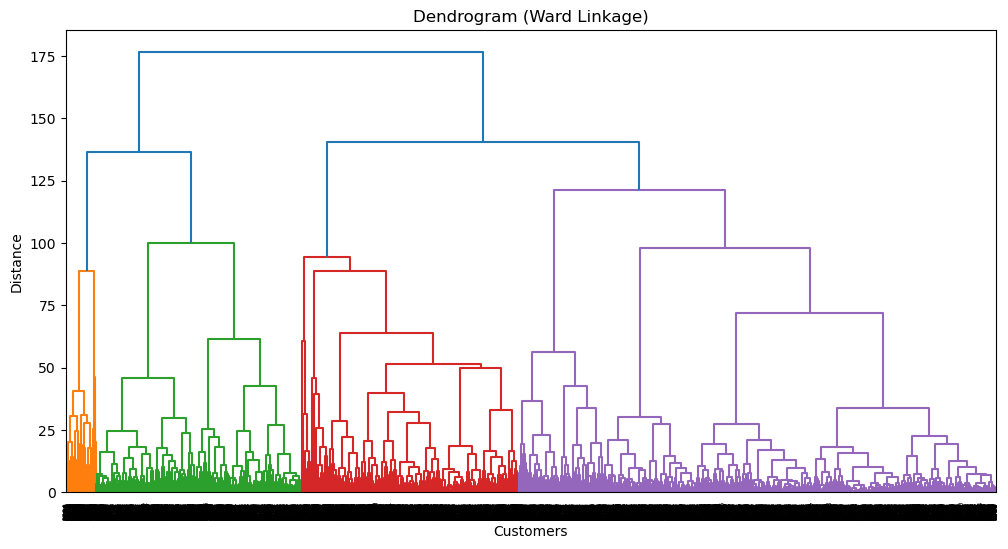

In [112]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [ ]:
#apply agglomorative algorith with 5 clusters based on the dendogram above
from sklearn.cluster import AgglomerativeClustering

n_clusters = 5 # change based on dendrogram

agg = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)

cluster_labels = agg.fit_predict(scaled_data)

# Add cluster labels back to original df
df["Cluster"] = cluster_labels

In [115]:
df["Cluster"].value_counts()

Cluster
1    3779
2    2087
0    1981
4     809
3     293
Name: count, dtype: int64

## **4. Visualize the Clustering Results**

In [118]:
cluster_summary = df.groupby("Cluster").mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,
0,992.418927,0.902723,1817.719495,611.748975,205.901540,0.829402,0.493914,0.036909,26.971731,5328.133710,1893.784156,461.548518,0.439174,11.925290
1,800.732616,0.836530,447.080699,239.502842,281.782868,0.407249,0.087274,0.058067,8.005822,2816.389885,831.057601,475.537665,0.053072,11.867425
2,3387.668140,0.950875,449.717192,187.937183,2812.708522,0.287465,0.110162,0.337969,7.035458,6629.973429,2695.062192,1890.916750,0.036444,11.915189
3,3596.301935,0.984145,8237.235427,3533.909249,872.797436,0.956221,0.606955,0.089409,98.235495,9582.252560,8119.205113,2003.518226,0.285711,11.962457
4,1095.551276,0.777546,415.566403,166.179419,1436.475721,0.403567,0.118664,0.229030,5.564895,2939.806345,761.376335,392.059959,0.179745,7.702101


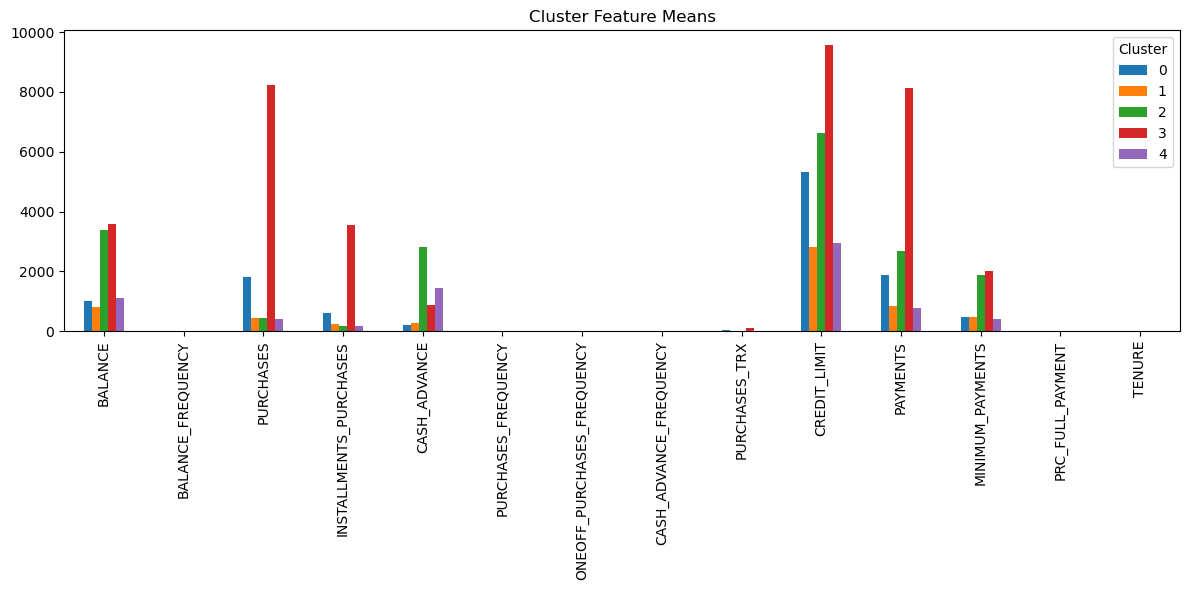

In [117]:
cluster_summary.T.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Feature Means")
plt.tight_layout()
plt.show()

In [ ]:
#cluster sizes
df["Cluster"].value_counts().sort_index()

Cluster
0    1981
1    3779
2    2087
3     293
4     809
Name: count, dtype: int64

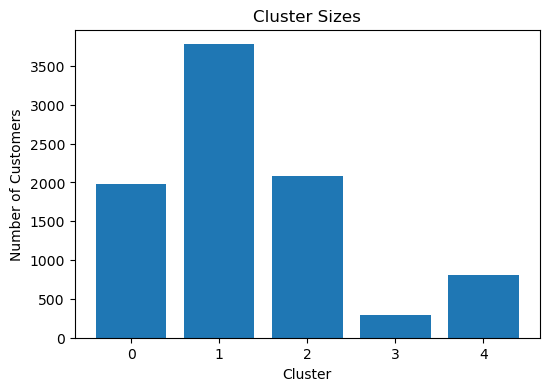

In [120]:
import matplotlib.pyplot as plt

cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Cluster Sizes")
plt.show()

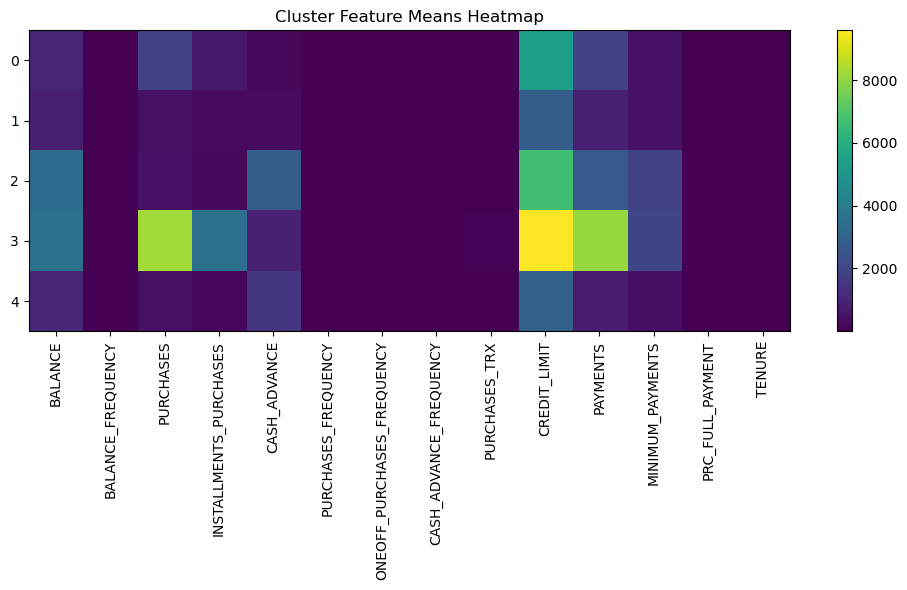

In [121]:
plt.figure(figsize=(10,6))
plt.imshow(cluster_summary, aspect='auto')
plt.colorbar()
plt.xticks(range(len(cluster_summary.columns)), cluster_summary.columns, rotation=90)
plt.yticks(range(len(cluster_summary.index)), cluster_summary.index)
plt.title("Cluster Feature Means Heatmap")
plt.tight_layout()
plt.show()

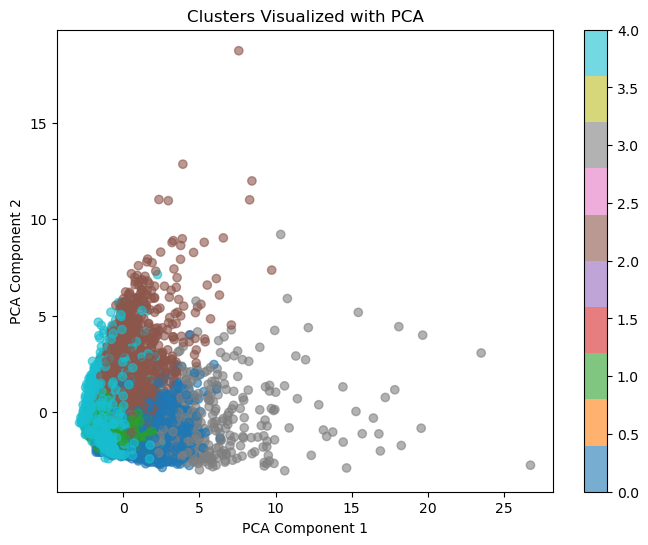

In [122]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_data[:,0], pca_data[:,1],
                      c=df["Cluster"],
                      cmap="tab10",
                      alpha=0.6)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters Visualized with PCA")
plt.colorbar(scatter)
plt.show()

## **5. Evaluate the Clustering**

In [123]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, df["Cluster"])
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.151


In [125]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"k = {k}, silhouette = {round(score,3)}")

k = 2, silhouette = 0.212
k = 3, silhouette = 0.142
k = 4, silhouette = 0.138
k = 5, silhouette = 0.151
k = 6, silhouette = 0.16
k = 7, silhouette = 0.142


## Clustering Quality Evaluation

The agglomerative clustering model was evaluated using the silhouette score.

The silhouette score obtained was **0.151** at 5 clusters, which indicates a weak clustering structure. From the silhouette scores above, it is shown that 2 clusters are best, yet weak as well.

Although some overlap between clusters is visible in the PCA projection, the clusters show meaningful behavioral separation. In particular, high-spending customers and low-activity customers form distinct groups, while moderate users form intermediate clusters.

The dendrogram also supported selecting 5 clusters, as a significant increase in linkage distance was observed before the final merges.

Overall, the clustering quality is acceptable for customer segmentation purposes. While the clusters are not perfectly separated, they are interpretable and reflect distinct spending and payment behaviors.

k = 2, silhouette = 0.212
k = 3, silhouette = 0.142
k = 4, silhouette = 0.138
k = 5, silhouette = 0.151
k = 6, silhouette = 0.16
k = 7, silhouette = 0.142


## **6. Explain whether the clustering quality and justify your reasoning**
## Clustering Quality Evaluation

The agglomerative clustering model was evaluated using the silhouette score.

The silhouette score obtained was **0.151** at K=5, which indicates a relatively weak clustering structure. This suggests that the clusters overlap to some extent and are not strongly separated in the feature space.

However, customer financial behavior data is typically noisy and continuous rather than naturally separable. The PCA visualization shows partial separation between high-spending customers and low-activity customers, while moderate users overlap across clusters.

The dendrogram indicated a clear increase in linkage distance before the final merges, supporting the selection of 5 clusters. Although the numerical separation is not strong, the clusters remain behaviorally interpretable.

Overall, the clustering provides meaningful segmentation insights, even though the statistical separation between clusters is limited.